# Boosting

Boosting is an ensemble regression model that works by training a series of models, $m_i, i \in 1, \dots, n$, on the residual data from the previous model. Each model is a simpler regression model.

## Algorithm

1. Let $\hat{y_1} = y$, where $y$ is the target training data.
2. For $m_i$, train the model on the training feature data $X$ and $\hat{y_i}$.
3. Predict the model $m_i$ according to the training feature data $X$; call the result $\hat{y}_{i+1}$.
4. Update $\hat{y}_{i+1}$: $\hat{y}_{i+1} \leftarrow \hat{y}_{i} - \hat{y}_{i+1}$
4. Repeat for $i \in 1, \dots, n$.
5. To predict a set of data $\hat{X}$, you simply predict each model $m_i$ with $\hat{x}$ and return the sum of the result.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from mlxtend.plotting import plot_decision_regions

import struct

sns.set_theme()

## Data Preprocessing
We will load in the AutoMPG data that we created in the preprocessing step:

In [54]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/AutoMPG-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
train_X

array([[ 1.49630792,  1.08923273,  0.66835485, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.50162428,  1.58460471, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.19472824,  1.1919262 , ...,  0.77258661,
        -0.46138749, -0.49701778],
       ...,
       [-0.85524411, -0.69460048,  0.27567634, ..., -1.29110112,
         2.16192996, -0.49701778],
       [ 0.3205319 , -0.29179943,  0.74689055, ..., -1.29110112,
         2.16192996, -0.49701778],
       [-0.85524411, -1.00149651, -0.87618062, ..., -1.29110112,
         2.16192996, -0.49701778]], shape=(279, 8))

## Implementation

In [72]:
def gradient_boosting(num_times, depth, train_X_data, train_y_data):
    next_y = np.copy(train_y_data[:, np.newaxis])
    regressors = []
    for i in range(num_times):
        regressor = DecisionTreeRegressor(max_depth = depth, random_state=42)
        regressor.fit(train_X_data, next_y)
        preds = regressor.predict(train_X_data)[:, np.newaxis]
        next_y -= preds
        regressors.append(regressor)
    return regressors

def predict_gradient_boosting(regressors, test_data):
    preds = regressors[0].predict(test_data)
    for (i, regressor) in enumerate(regressors[1:]):
        preds += regressor.predict(test_data)
    return preds

## Data Analysis

Here, we create a series of plots varying the number of estimators for our chosen data:

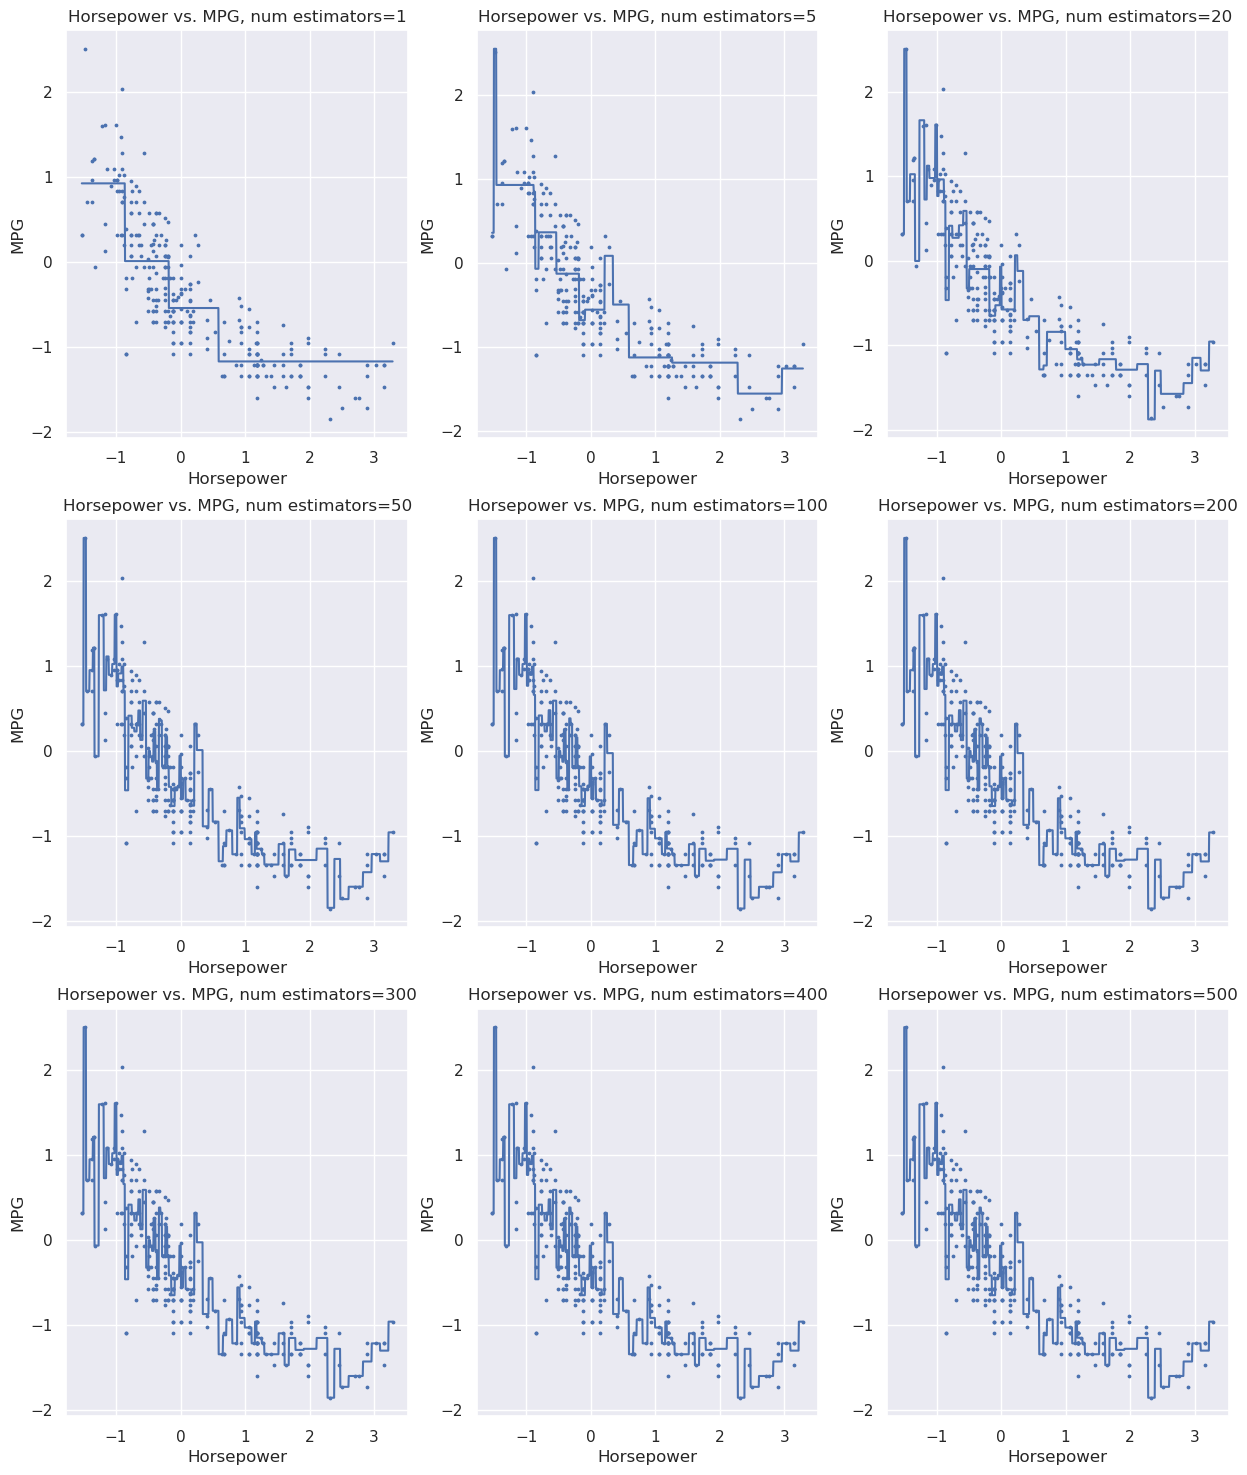

In [73]:
fig, axs = plt.subplots(3, 3, figsize = (15, 18))
t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)[:, np.newaxis]
mse_vals = []
estimator_counts = [1, 5, 20, 50, 100, 200, 300, 400, 500]

for (k, estimator_count) in enumerate(estimator_counts):
    regressors = gradient_boosting(estimator_count, 2, train_X[:, 2:3], train_y)
    t_y = predict_gradient_boosting(regressors, t)

    i, j = k // 3, k % 3

    axs[i, j].plot(t, t_y)
    axs[i, j].set_xlabel("Horsepower")
    axs[i, j].set_ylabel("MPG")
    axs[i, j].set_title(f"Horsepower vs. MPG, num estimators={estimator_count}")
    axs[i, j].scatter(train_X[:, 2], train_y[:], s = 3)

    preds = predict_gradient_boosting(regressors, test_X[:, 2:3])
    mse = mean_squared_error(test_y, preds)
    mse_vals.append(mse)
plt.show()

We can see that the plots become quite oscillatory, looking almost exactly like the high depth decision trees.

Now, output MSE for each level:

In [74]:
for (j, mse) in enumerate(mse_vals):
    print(f"Number of estimators {estimator_counts[j]:2d}: MSE {mse: 1.3f}")

Number of estimators  1: MSE  0.936
Number of estimators  5: MSE  0.817
Number of estimators 20: MSE  0.809
Number of estimators 50: MSE  0.804
Number of estimators 100: MSE  0.802
Number of estimators 200: MSE  0.802
Number of estimators 300: MSE  0.802
Number of estimators 400: MSE  0.802
Number of estimators 500: MSE  0.802


Even though the data becomes oscillatory, the MSE still strictly decreases as the number of estimators increases.

Now, train the full dimension data with gradient boosting:

In [75]:
mse_vals = []
estimator_counts = [1, 5, 20, 50, 100, 200, 300, 400, 500]

for (k, estimator_count) in enumerate(estimator_counts):
    regressors = gradient_boosting(estimator_count, 2, train_X, train_y)
    preds = predict_gradient_boosting(regressors, test_X)
    mse = mean_squared_error(test_y, preds)
    mse_vals.append(mse)

And output MSEs:

In [64]:
for (j, mse) in enumerate(mse_vals):
    print(f"Number of estimators {estimator_counts[j]:2d}: MSE {mse: 1.3f}")

Number of estimators  1: MSE  1.068
Number of estimators  5: MSE  1.044
Number of estimators 20: MSE  0.994
Number of estimators 50: MSE  0.941
Number of estimators 100: MSE  0.952
Number of estimators 200: MSE  0.957
Number of estimators 300: MSE  0.958
Number of estimators 400: MSE  0.962
Number of estimators 500: MSE  0.960


We can see that the MSE is smallest when the number of estimators is around 50 for the whole dataset.